<a href="https://colab.research.google.com/github/4zmyyy/AMPG-banten-database/blob/main/Banten-2024-electoral-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

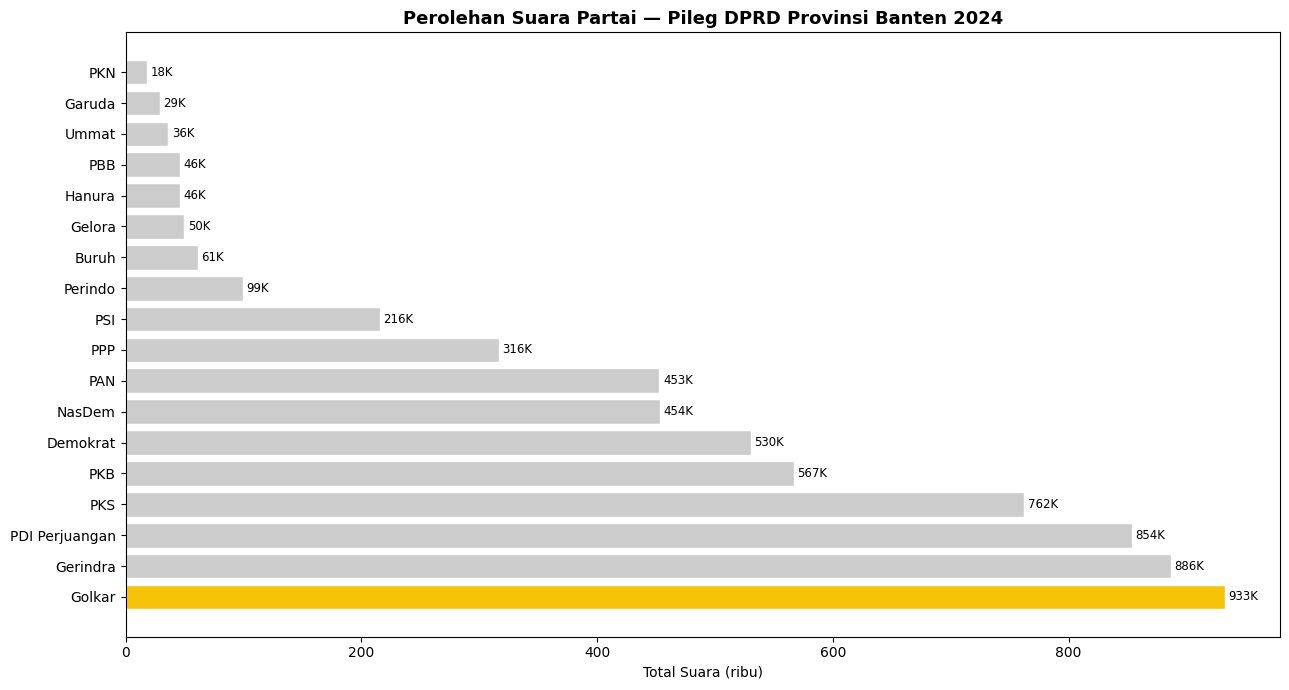

/tmp/ipykernel_2782/399848830.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_golkar['dapil'], rotation=45, ha='right', fontsize=9)
/tmp/ipykernel_2782/399848830.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(df_golkar['dapil'], rotation=45, ha='right', fontsize=9)


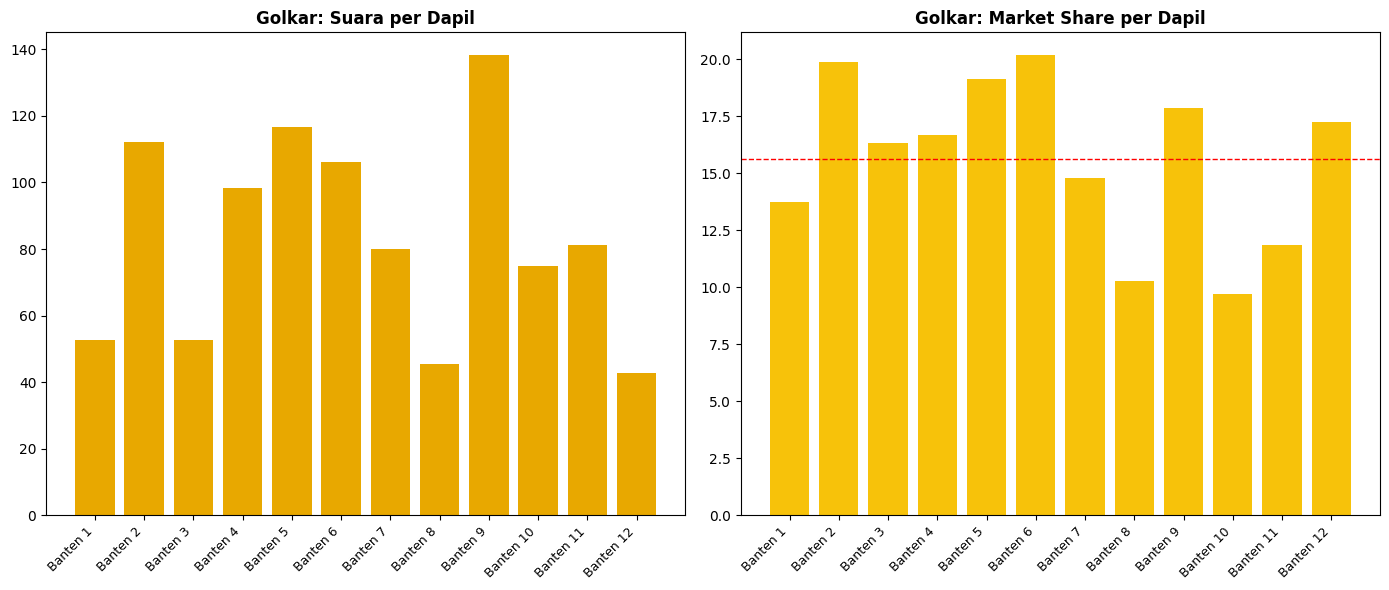

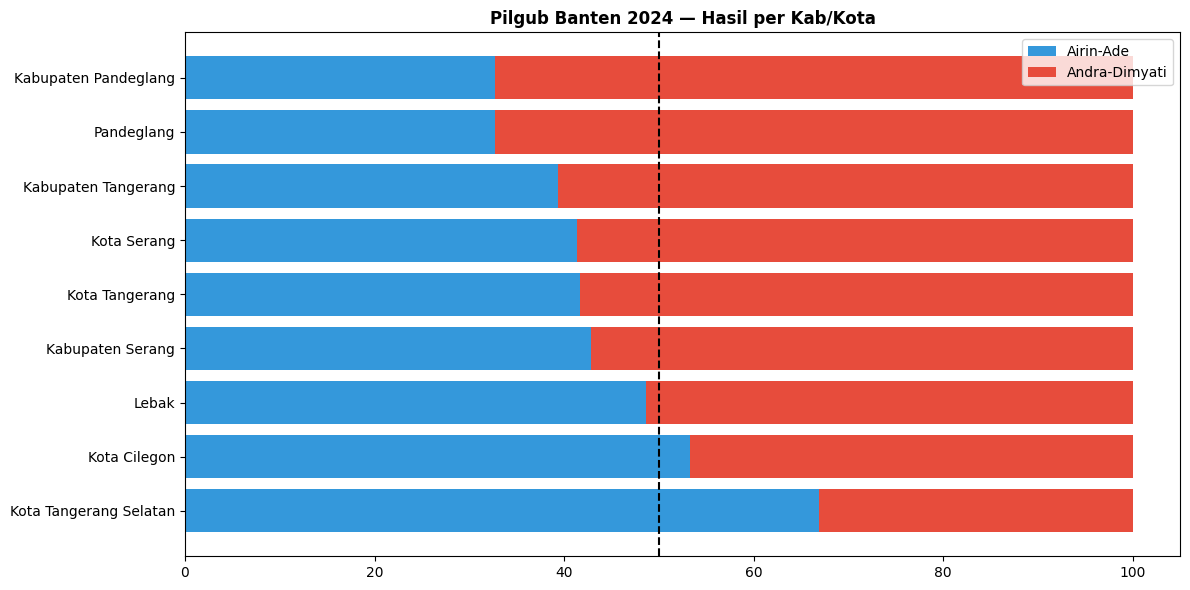

Semua chart selesai!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = pd.read_csv('pileg_partai_per_dapil.csv')
df_golkar = pd.read_csv('golkar_per_dapil.csv')
df_pilgub = pd.read_csv('pilgub_per_kab_kota.csv')

parties = df[df['partai'] != 'total_suara_sah'].copy()
parties_sorted = parties.sort_values('total', ascending=False)

# Chart 1 - Ranking partai
fig, ax = plt.subplots(figsize=(13, 7))
colors = ['#F7C20A' if p == 'Golkar' else '#CCCCCC' for p in parties_sorted['partai']]
bars = ax.barh(parties_sorted['partai'], parties_sorted['total'] / 1000, color=colors, edgecolor='white')
for bar, val in zip(bars, parties_sorted['total']):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2, f'{val/1000:.0f}K', va='center', fontsize=8.5)
ax.set_xlabel('Total Suara (ribu)')
ax.set_title('Perolehan Suara Partai — Pileg DPRD Provinsi Banten 2024', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('01_ranking_partai.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 2 - Golkar per dapil
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax1, ax2 = axes
ax1.bar(df_golkar['dapil'], df_golkar['suara_golkar']/1000, color='#E8A800')
ax1.set_xticklabels(df_golkar['dapil'], rotation=45, ha='right', fontsize=9)
ax1.set_title('Golkar: Suara per Dapil', fontweight='bold')
ax2.bar(df_golkar['dapil'], df_golkar['share_pct'], color='#F7C20A')
ax2.set_xticklabels(df_golkar['dapil'], rotation=45, ha='right', fontsize=9)
ax2.axhline(y=df_golkar['share_pct'].mean(), color='red', linestyle='--', linewidth=1)
ax2.set_title('Golkar: Market Share per Dapil', fontweight='bold')
plt.tight_layout()
plt.savefig('02_golkar_per_dapil.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 3 - Pilgub
df_pg = df_pilgub.drop_duplicates('kab_kota').sort_values('andra_pct', ascending=True)
fig, ax = plt.subplots(figsize=(12, 6))
y = range(len(df_pg))
ax.barh(y, df_pg['airin_pct'], color='#3498db', label='Airin-Ade')
ax.barh(y, df_pg['andra_pct'], left=df_pg['airin_pct'], color='#e74c3c', label='Andra-Dimyati')
ax.axvline(x=50, color='black', linestyle='--')
ax.set_yticks(y)
ax.set_yticklabels(df_pg['kab_kota'])
ax.set_title('Pilgub Banten 2024 — Hasil per Kab/Kota', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('03_pilgub.png', dpi=150, bbox_inches='tight')
plt.show()

print("Semua chart selesai!")

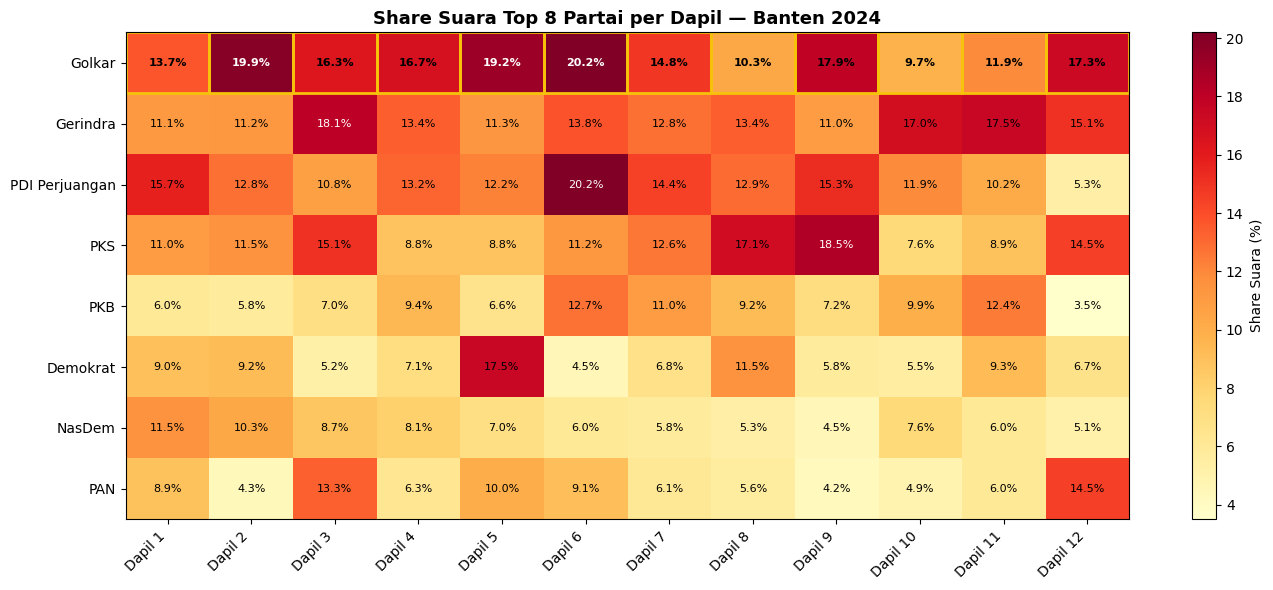

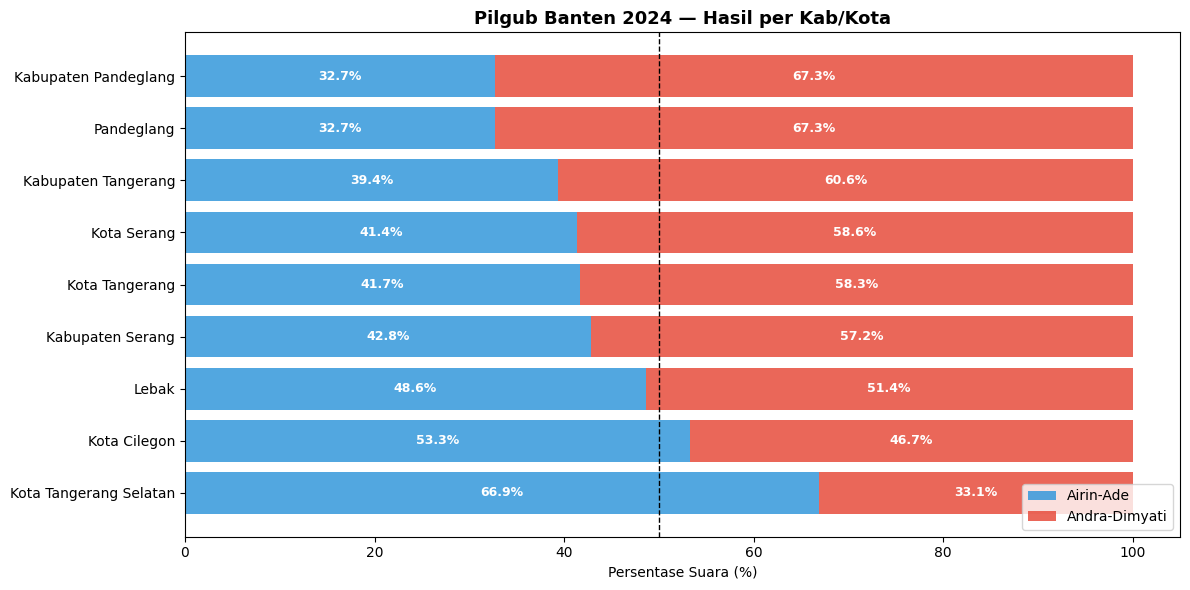

Done!


In [2]:
# Chart Heatmap Top 8 Partai
dapil_cols = [f'dapil_{i}' for i in range(1, 13)]
top_parties = ['Golkar', 'Gerindra', 'PDI Perjuangan', 'PKS', 'PKB', 'Demokrat', 'NasDem', 'PAN']

share_data = {}
total_row = df[df['partai'] == 'total_suara_sah'][dapil_cols].values[0]
for party in top_parties:
    row = df[df['partai'] == party][dapil_cols].values[0]
    share_data[party] = (row / total_row * 100).round(1)

share_df = pd.DataFrame(share_data, index=[f'Dapil {i}' for i in range(1, 13)]).T

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(share_df.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(12))
ax.set_xticklabels([f'Dapil {i}' for i in range(1, 13)], rotation=45, ha='right')
ax.set_yticks(range(len(top_parties)))
ax.set_yticklabels(top_parties)
for i in range(len(top_parties)):
    for j in range(12):
        val = share_df.values[i, j]
        color = 'white' if val > 18 else 'black'
        if top_parties[i] == 'Golkar':
            ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor='#F7C20A', linewidth=2))
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center', fontsize=8, color=color,
                fontweight='bold' if top_parties[i]=='Golkar' else 'normal')
plt.colorbar(im, ax=ax, label='Share Suara (%)')
ax.set_title('Share Suara Top 8 Partai per Dapil — Banten 2024', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('03_heatmap_partai.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart Pilgub per Kab/Kota
df_pg = df_pilgub.drop_duplicates('kab_kota').sort_values('andra_pct', ascending=True)
fig, ax = plt.subplots(figsize=(12, 6))
y = range(len(df_pg))
ax.barh(y, df_pg['airin_pct'], color='#3498db', alpha=0.85, label='Airin-Ade')
ax.barh(y, df_pg['andra_pct'], left=df_pg['airin_pct'], color='#e74c3c', alpha=0.85, label='Andra-Dimyati')
ax.axvline(x=50, color='black', linestyle='--', linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(df_pg['kab_kota'], fontsize=10)
ax.set_xlabel('Persentase Suara (%)')
ax.set_title('Pilgub Banten 2024 — Hasil per Kab/Kota', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
for i, row in enumerate(df_pg.itertuples()):
    ax.text(row.airin_pct/2, i, f'{row.airin_pct:.1f}%', ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    ax.text(row.airin_pct + row.andra_pct/2, i, f'{row.andra_pct:.1f}%', ha='center', va='center', color='white', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('04_pilgub_per_kab_kota.png', dpi=150, bbox_inches='tight')
plt.show()

print("Done!")

In [5]:
!pip install pillow

In [6]:
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter

fig, ax = plt.subplots(figsize=(13, 7))

parties_list = parties_sorted['partai'].tolist()
values = (parties_sorted['total'] / 1000).tolist()
colors = ['#F7C20A' if p == 'Golkar' else '#CCCCCC' for p in parties_list]

def animate(frame):
    ax.clear()
    current_values = [min(v, v * frame / 40) for v in values]
    bars = ax.barh(parties_list, current_values, color=colors, edgecolor='white')

    for bar, val, full_val in zip(bars, current_values, values):
        if val > 5:
            ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                    f'{full_val:.0f}K', va='center', fontsize=8)

    ax.set_xlim(0, max(values) * 1.15)
    ax.set_xlabel('Total Suara (ribu)', fontsize=11)
    ax.set_title('Perolehan Suara Partai — Pileg DPRD Provinsi Banten 2024\n(Golkar = highlight kuning)',
                 fontsize=13, fontweight='bold')

    golkar_patch = mpatches.Patch(color='#F7C20A', label='Golkar (Peringkat 1)')
    others_patch = mpatches.Patch(color='#CCCCCC', label='Partai lain')
    ax.legend(handles=[golkar_patch, others_patch], loc='lower right')

ani = animation.FuncAnimation(fig, animate, frames=50, interval=50, repeat=False)
ani.save('banten_2024_animated.gif', writer=PillowWriter(fps=25))
plt.close()
print("GIF saved! Download dari sidebar kiri.")

GIF saved! Download dari sidebar kiri.


In [7]:
import os
print(os.listdir('.'))

['.config', 'banten_2024_animated.gif', 'pileg_partai_per_dapil.csv', 'golkar_per_dapil.csv', 'pilgub_per_kab_kota.csv', '04_pilgub_per_kab_kota.png', '02_golkar_per_dapil.png', '03_pilgub.png', '03_heatmap_partai.png', '01_ranking_partai.png', 'sample_data']
